## Iris-Flower Detection Model Using KNN


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [4]:
df["Species"] = df["Species"].map({
    "Iris-setosa" : 0,
    "Iris-versicolor" : 1,
    "Iris-virginica" : 2
})

In [5]:
df["Species"].unique

<bound method Series.unique of 0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: Species, Length: 150, dtype: int64>

In [6]:
X = df.drop(["Species","Id"],axis=1)
Y = df["Species"]

In [7]:
print(X.shape)

(150, 4)


In [8]:
print(Y.shape)

(150,)


In [9]:
mean = np.mean(X,axis=0)
std = np.std(X,axis=0)
X = (X-mean)/std

In [10]:
X.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,1.500000e+02,1.500000e+02,1.500000e+02,1.500000e+02
mean,-4.736952e-16,-6.631732e-16,3.315866e-16,-2.842171e-16
std,1.003350e+00,1.003350e+00,1.003350e+00,1.003350e+00
min,-1.870024e+00,-2.438987e+00,-1.568735e+00,-1.444450e+00
25%,-9.006812e-01,-5.877635e-01,-1.227541e+00,-1.181504e+00
50%,-5.250608e-02,-1.249576e-01,3.362659e-01,1.332259e-01
75%,6.745011e-01,5.692513e-01,7.627586e-01,7.905908e-01
max,2.492019e+00,3.114684e+00,1.786341e+00,1.710902e+00


In [15]:
X = X.to_numpy()
Y = Y.to_numpy()

In [16]:
np.random.seed(42)
indices = np.arange(len(X))
np.random.shuffle(indices)

X = X[indices]
Y = Y[indices]
split_ratio = 0.8
split_index = int(len(X) * split_ratio)
X_train = X[:split_index]
X_test = X[split_index:]

Y_train = Y[:split_index]
Y_test = Y[split_index:]



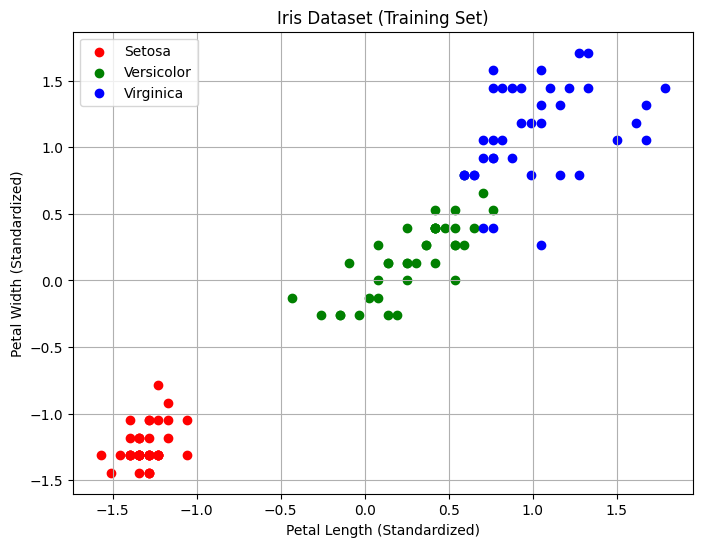

In [92]:
plt.figure(figsize=(8,6))
colors = ['red', 'green', 'blue']
labels = ['Setosa', 'Versicolor', 'Virginica']
for i in range(3):
    plt.scatter(
        X_train[Y_train == i, 2],   # Petal Length
        X_train[Y_train == i, 3],   # Petal Width
        color=colors[i],
        label=labels[i]
    )
plt.xlabel("Petal Length (Standardized)")
plt.ylabel("Petal Width (Standardized)")
plt.title("Iris Dataset (Training Set)")
plt.legend()
plt.grid(True)

plt.show()

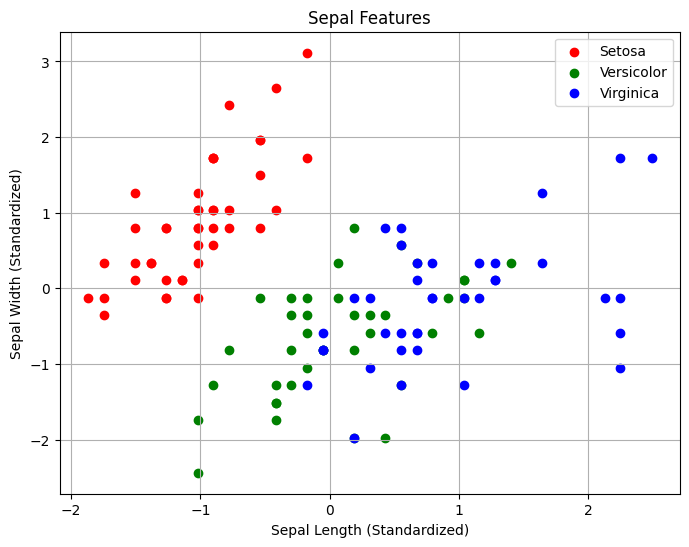

In [94]:
plt.figure(figsize=(8,6))

colors = ['red', 'green', 'blue']
labels = ['Setosa', 'Versicolor', 'Virginica']

for i in range(3):
    plt.scatter(
        X_train[Y_train == i, 0],   # Sepal Length
        X_train[Y_train == i, 1],   # Sepal Width
        color=colors[i],
        label=labels[i]
    )

plt.xlabel("Sepal Length (Standardized)")
plt.ylabel("Sepal Width (Standardized)")
plt.title("Sepal Features")
plt.legend()
plt.grid(True)

plt.show()

In [45]:
def euclidean_distance(x1,x2):
    return np.sqrt(np.sum((x1-x2)**2))

In [84]:
def predict(test_sample,X_train,Y_train,K):
    distances = []
    for train_sample in X_train:
        distance = euclidean_distance(test_sample,train_sample)
        distances.append(distance)
    sorted_indices = np.argsort(distances)
    k_indices = sorted_indices[:K]
    k_label = Y_train[k_indices]
    votes = np.bincount(k_label)
    prediction = np.argmax(votes)
    return prediction

In [ ]:
prediction = predict(X_test[0], X_train, Y_train, 3)

print("Predicted:", prediction)
print("Actual:", Y_test[0])

Predicted: 1
Actual: 1


In [86]:
predictions = []

for sample in X_test:
    predictions.append(predict(sample, X_train, Y_train, 3))
    
predictions = np.array(predictions)

accuracy = np.mean(predictions == Y_test)

print(accuracy)
    

0.9666666666666667


In [87]:
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 96.67%


In [89]:
def visualize_knn(test_sample, actual_label, X_train, Y_train, k):

    # Step 1: Calculate distances
    distances = []

    for train_sample in X_train:
        distance = euclidean_distance(test_sample, train_sample)
        distances.append(distance)

    # Step 2: Find k nearest neighbors
    sorted_indices = np.argsort(distances)
    k_indices = sorted_indices[:k]

    # Step 3: Predict class
    k_labels = Y_train[k_indices]
    votes = np.bincount(k_labels)
    prediction = np.argmax(votes)

    # Step 4: Plot
    plt.figure(figsize=(8,6))

    colors = ['red', 'green', 'blue']
    labels = ['Setosa', 'Versicolor', 'Virginica']

    # Plot all training samples
    for i in range(3):
        plt.scatter(
            X_train[Y_train == i, 2],     # Petal Length
            X_train[Y_train == i, 3],     # Petal Width
            color=colors[i],
            label=labels[i]
        )

    # Plot test sample
    plt.scatter(
        test_sample[2],
        test_sample[3],
        marker='*',
        color='black',
        s=250,
        label='Test Sample'
    )

    # Plot nearest neighbors
    neighbors = X_train[k_indices]

    plt.scatter(
        neighbors[:,2],
        neighbors[:,3],
        facecolors='none',
        edgecolors='black',
        s=250,
        linewidths=2,
        label='Nearest Neighbors'
    )

    # Draw lines
    for neighbor in neighbors:
        plt.plot(
            [test_sample[2], neighbor[2]],
            [test_sample[3], neighbor[3]],
            '--',
            color='black'
        )

    plt.xlabel("Petal Length (Standardized)")
    plt.ylabel("Petal Width (Standardized)")
    plt.title(f"KNN Visualization (k={k})")
    plt.grid(True)
    plt.legend()

    plt.show()

    print("Predicted:", prediction)
    print("Actual   :", actual_label)

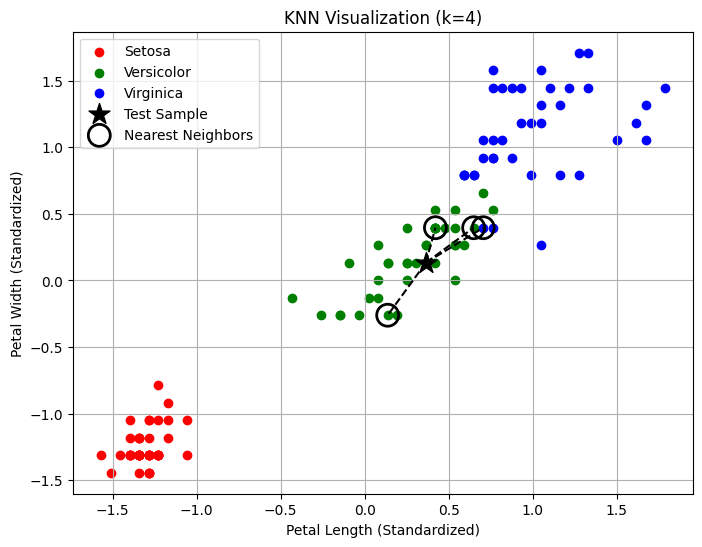

Predicted: 1
Actual   : 1


In [ ]:
visualize_knn(
    X_test[20],
    Y_test[20],
    X_train,
    Y_train,
    k=3
)